In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

### Feature importance using RandomForest

In [4]:
import pandas as pd

In [5]:
from sklearn.ensemble import RandomForestRegressor

In [6]:
df = pd.read_excel("combined_data_cleaned.xlsx")

In [7]:
df = df.drop("Unnamed: 0",axis=1)


In [8]:
df.head()

,R_temp,R_vol,H2_flow,feed1_flow,frac_gly_in,PDO_fraction,gly_conv
0,191.708108,845.300093,22.241924,195.323931,0.543175,0.097191,19.930615
1,189.777284,1216.133737,23.466869,165.372420,0.484108,0.119857,28.271647
2,287.399527,949.374042,23.579903,190.062893,0.799217,0.109756,15.436754
3,181.768219,1901.213276,22.106265,114.969479,0.600098,0.157642,31.320362
4,238.087179,890.589842,19.807418,182.374191,0.576989,0.096571,18.554813


In [9]:
x = df.iloc[:,0:5]
y = df.iloc[:,-2]

In [10]:
rfr  = RandomForestRegressor()

In [11]:
rfr.fit(x,y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
importance_arr = rfr.feature_importances_

In [13]:
import numpy as np

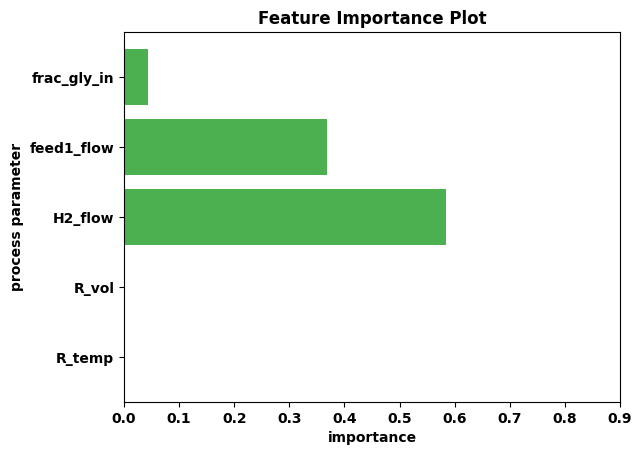

In [33]:
import matplotlib.pyplot as plt

categories = ['R_temp', 'R_vol', 'H2_flow', 'feed1_flow','frac_gly_in']
values = importance_arr

plt.barh(categories, values, color='#4CAF50')

plt.xticks(np.arange(0,1,0.1))

plt.xlabel('importance')
plt.ylabel('process parameter')
plt.title('Feature Importance Plot')

plt.show()

#### glycerol mole flow rate and hydrogen mole flow rate are contributing more to the PDO_fraction in the product stream

## #feature importance using SHAP

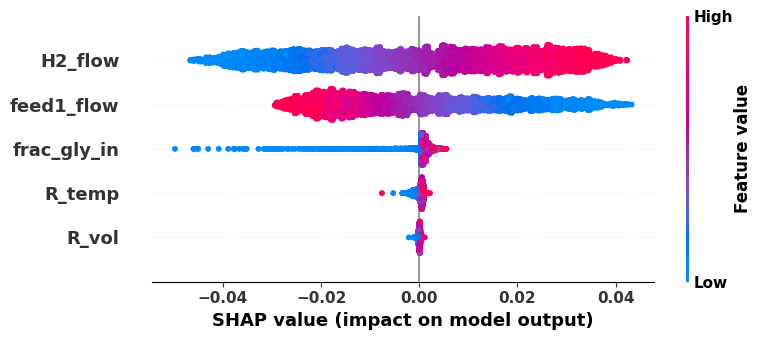

In [15]:
import shap

explainer = shap.TreeExplainer(rfr)

shap_values = explainer.shap_values(x)

shap.summary_plot(
    shap_values,
    x
)

<h3>SHAP Analysis Results</h3>

<p>
The <span style="color:red;"><b>H₂ flow rate</b></span> is the most influential variable affecting PDO production.
</p>

<p>
The <span style="color:blue;"><b>feed flow rate</b></span> has an inverse effect on PDO production.
</p>

<p>
<span style="color:green;"><b>Reactor temperature</b></span> and
<span style="color:orange;"><b>reactor volume</b></span>
show minimal influence within the investigated range.
</p>

### Permutation importance

In [23]:
from sklearn.inspection import permutation_importance

In [30]:
results = permutation_importance(rfr,
                       x,
                       y,
                      n_repeats=10,
                      random_state=42)


In [31]:
print(results.importances_mean)

[2.91936602e-03 3.74854885e-04 1.15777230e+00 7.72415155e-01
 1.01124756e-01]


In [42]:
features = ['R_temp', 'R_vol', 'H2_flow', 'feed1_flow','frac_gly_in']
y = results.importances_mean
y

array([2.91936602e-03, 3.74854885e-04, 1.15777230e+00, 7.72415155e-01,
       1.01124756e-01])

In [41]:
# plt.figure(figsize=(12,8))
# plt.pie(
#     y,
#     labels= features,
#     autopct =' %0.1f%%'
# )
# plt.show()